### Set up

In [89]:
# imports

from explore_import import  *
import tpp_preprocess as tpp
import hpp_checker as hpp
import data_preprocess as dt

import pyteomics.auxiliary as aux
from pathlib import Path
import os, re, subprocess
warnings.simplefilter(action='ignore', category=FutureWarning)
import ast

In [3]:
# base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
data_dir=f"{root}/oui-discovery-vv-data/raw/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525"
processed_dir=f"{root}/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525"
r_path="Rscript"
gwalk_work_dir=root
gwalk_script="Run_group_walk_tppfragpipe.R"

In [4]:
# replicate insides of data directory to preprocessed directory

#get insides of data directory
data_paths=dt.list_files(data_dir)

#replicate
for parent in data_paths.keys():
    new_parent=parent.replace(data_dir, processed_dir)
    os.makedirs(new_parent, exist_ok=True)

tpp_pride_reanalysis_arch230525/
    PXD014258/
        PXD014258-openprot/
            ESC-HF-Sample-MCF_openprot_PeptideProphet.pep.xml.index
            ESC-HF-Sample-MCF5.RAW.pep.xml
            ESC-HF-Sample-BT474_1_RAW.pep.xml
            ESC-HF-SampleHela_openprot_ProteinProphet.pep.prot.xml
            ESC-HF-SampleHela5.RAW.pep.xml
            ESC-HF-SampleHela_openprot_PeptideProphet.pep.xml.index
            ESC-HF-Sample-BT474_3_RAW.pep.xml
            ESC-HF-Sample-BT474_5_RAW.pep.xml
            ESC-HF-SampleHela3.RAW.pep.xml
            ESC-HF-Sample-MCF1.RAW.pep.xml
            ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml
            ESC-HF-SampleHela1.RAW.pep.xml
            ESC-HF-Sample-MCF3.RAW.pep.xml
            ESC-HF-Sample-BT474_openprot_ProteinProphet.pep.prot.xml
            ESC-HF-SampleHela2.RAW.pep.xml
            ESC-HF-Sample-MCF_openprot_ProteinProphet.pep.prot.xml
            ESC-HF-Sample-MCF_openprot_PeptideProphet.pep.xml
            ESC-HF-S

### Load and process PeptideProphet files

In [5]:
def classify_leadprot(x):
    x=x.replace("decoy_","")
    if 'CONTAMINANT' in x.upper():
        return 'Contam'
    elif x.startswith('II_') or x.startswith('IP_'):
        return 'NonCanon'
        # Ensembl is canonical
    else:
        return 'Canon'

def is_peptide_canonical(x):
    '''x is the list of protein classes'''
    if np.array([_=='Contam' for _ in x]).any():
        return 'Contam'
    if np.array([_=='Canon' for _ in x]).any():
        return 'Canonical'
    return 'NonCanonical'

def classifiy_mods(row):
    if len(row.modifications)==0:
        return 'Unmodified'
    else:
        return 'Expected'

def custom_subgroup_filter(data_,key):
    filtered_subgroups = []
    for c,df in data_.groupby("FDRGroup").__iter__():
        tmp = aux.target_decoy.qvalues(df, key=key, reverse=True, is_decoy=df.database=='D',
                                      formula=1, full_output=True, q_label='custom_q')
        filtered_subgroups.append(tmp)

    return pd.concat(filtered_subgroups, ignore_index=True)

In [6]:
def col_isna(df,col):
    return 100-round((df[col].isna().value_counts()[False]/len(df))*100,4)

In [7]:
qval_score='peptideprophet_probability'

for parent, files in data_paths.items():
    new_parent=parent.replace(data_dir,processed_dir)
    dataset, database = parent.split("/")[-1].split("-")
    for file in files:
        if file.endswith("_PeptideProphet.pep.xml"):
            # read PeptideProphet output
            pepxml_path=os.path.join(parent, file)
            data=pepxml.DataFrame(pepxml_path)
            print(f"{dataset}|{database}|{file} N of discoveries: {len(data)}")
            
            #pin dataset and search_database and spectrum_file
            data["dataset"] = dataset
            data["search_database"] = database
            data["spectrum_file"] = file.replace("_PeptideProphet.pep.xml","").replace(f"_{database}","")
            
            #pin T/D database
            data["database"]=data["protein"].apply(tpp.get_database_tpp)
            td_counts = round((data["database"].value_counts()/len(data))*100,4)
            print(f"{dataset}|{database}|{file} targets and decoys and NA: {td_counts['T']} and {td_counts['D']} and {col_isna(data,'database')}")

            #calculate global q-value on peptideprophet_probability
            print(f"{dataset}|{database}|{file} {qval_score} range and NA: {min(data[qval_score])} - {max(data[qval_score])} and {col_isna(data,qval_score)}")
            data = aux.target_decoy.qvalues(data,
                                            key=qval_score,
                                            reverse=True,
                                            is_decoy=(data.database == 'D'),
                                            q_label='global_q',
                                            formula=1,
                                            full_output=True)
            print(f"{dataset}|{database}|{file} 'global_q' range and NA: {min(data['global_q'])} - {max(data['global_q'])} and {col_isna(data,'global_q')}")

            #calculate PEP
            data['PEP'] = 1 - data[qval_score]
            
            #pin helpfull labels
            data["peptide_class"]=data["protein"].apply(tpp.classify_peptide_tpp)
            
            #pin subgroups
            data['protein_classes'] = data.protein.apply(lambda x: np.unique([classify_leadprot(_) for _ in x]))
            data['isCanonical'] = data.protein_classes.apply(is_peptide_canonical)
            data['isModified']  = data.apply(classifiy_mods,axis=1)

            # prepare to group-wise
            data['isTarget'] = data.database.apply(lambda x: x=='T')
            data['FDRGroup'] = data.isCanonical
            fdrgroup_counts = round((data["FDRGroup"].value_counts()/len(data))*100,4)
            counts_str = ", ".join(
                f"{key} {fdrgroup_counts[key]}%"
                for key in list(fdrgroup_counts.keys())
            )
            na_count = col_isna(data, 'FDRGroup')
            print(f"{dataset}|{database}|{file} {counts_str}, NA {na_count}")
            
            # calculate to group-wise
            data = custom_subgroup_filter(data, qval_score)
            print(f"{dataset}|{database}|{file} 'custom_q' range and NA: {min(data['custom_q'])} - {max(data['custom_q'])} and {col_isna(data,'custom_q')}")        
            
            #save for Group-walk
            basename = os.path.basename(pepxml_path).split('.')[0]
            gwalk_input = os.path.join(new_parent, f"{basename}.csv")
            data.to_csv(gwalk_input)
            
            #run Group-walk
            dataset_dir = new_parent
            working_dir = gwalk_work_dir
            file_name = os.path.basename(gwalk_input)
            print(f"Run Group-walk on {gwalk_input}")
            command = (
                f"module load r && {r_path} {gwalk_script} {dataset_dir} {working_dir} {file_name}"
            )
            
            _ = subprocess.run(command, shell=True, check=True)
            
            qwalk_output = os.path.join(new_parent,"groupwalk_output_"+file_name)
            
            #check group-walk
            data2=pd.read_csv(qwalk_output)
            print(f"{dataset}|{database}|{file} 'group_q_prob' range and NA: {min(data2['group_q_prob'])} - {max(data2['group_q_prob'])} and {col_isna(data2,'group_q_prob')}")
            del data2
            
#            break
#    break

PXD014258|openprot|ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml N of discoveries: 48292
PXD014258|openprot|ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml targets and decoys and NA: 94.1771 and 5.8229 and 0.0
PXD014258|openprot|ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml peptideprophet_probability range and NA: 0.05 - 1.0 and 0.0
PXD014258|openprot|ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml 'global_q' range and NA: 0.0 - 0.06182937554969217 and 0.0
PXD014258|openprot|ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml Canonical 84.4053%, Contam 8.5356%, NonCanonical 7.0591%, NA 0.0
PXD014258|openprot|ESC-HF-Sample-BT474_openprot_PeptideProphet.pep.xml 'custom_q' range and NA: 0.0 - 0.809447983014862 and 0.0
Run Group-walk on /project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525/PXD014258/PXD014258-openprot/ESC-HF-Sample-BT474_openprot_PeptideProphet.csv
PXD0

### PSM -> peptide

In [7]:
processed_paths=dt.list_files(processed_dir)

tpp_pride_reanalysis_arch230525/
    PXD014258/
        PXD014258-openprot/
            ESC-HF-SampleHela_openprot_PeptideProphet.csv
            groupwalk_output_ESC-HF-SampleHela_openprot_PeptideProphet.csv
            groupwalk_output_ESC-HF-Sample-BT474_openprot_PeptideProphet.csv
            ESC-HF-Sample-MCF_openprot_PeptideProphet.csv
            groupwalk_output_ESC-HF-Sample-MCF_openprot_PeptideProphet.csv
            ESC-HF-Sample-BT474_openprot_PeptideProphet.csv
            .ipynb_checkpoints/
                groupwalk_output_ESC-HF-Sample-BT474_openprot_PeptideProphet-checkpoint.csv
        PXD014258-trembl/
            ESC-HF-SampleHela_trembl_PeptideProphet.csv
            groupwalk_output_ESC-HF-Sample-MCF_trembl_PeptideProphet.csv
            groupwalk_output_ESC-HF-SampleHela_trembl_PeptideProphet.csv
            groupwalk_output_ESC-HF-Sample-BT474_trembl_PeptideProphet.csv
            ESC-HF-Sample-MCF_trembl_PeptideProphet.csv
            ESC-HF-Sample-BT474_trembl

In [40]:
#read the files with FDP ranks
root_fdp = '/project/def-marie87/vvshazia/pride_reanalysis/Ionbot_FDP/IonbotData_tpp_fragpipe_ranks_290925'
#global
global_fdp_file = f'{root_fdp}/results/peptide_level/all_bysample_stats.csv'
global_fdp = pd.read_csv(global_fdp_file)
#leave TPP
global_fdp = global_fdp[global_fdp.search_type == 'TPP_PTM']
#correct sample names
global_fdp['sample'] = global_fdp['sample'].str.split('_fdp').str[0]

#subset
subset_fdp_file = f'{root_fdp}/results/peptide_level/all_bysample_stats_subsets.csv'
subset_fdp = pd.read_csv(subset_fdp_file)
#leave TPP
subset_fdp = subset_fdp[subset_fdp.search_type == 'TPP_PTM']
#correct sample names
subset_fdp['sample'] = subset_fdp['sample'].str.split('_fdp').str[0].replace('canonical_|noncanonical_', '', regex=True)
#correct subset names
subset_fdp['subset'] = subset_fdp['subset'].map({'canonical':'Canonical','noncanonical':'NonCanonical'})

In [48]:
qval_score='peptideprophet_probability'

for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    dataset, database = parent.split("/")[-1].split("-")
    for file in files:
        # omit group-walk output PSM-level and newly added peptide-level and group-walk output peptide-level
        if (not file.startswith("groupwalk_output_")) and (not file.endswith("_pep.csv")) :
            spectrum_file = file.split(".")[0]

            data = pd.read_csv(os.path.join(parent, file))
            print(f"PSM -> peptide : {file}")
            #drop PSM-level q-values
            data.drop(['global_q','custom_q'],inplace=True,axis=1) 

            # select high-scoring PSMs
            data_peptide = data.sort_values(qval_score, ascending=False).drop_duplicates("peptide", keep="first")
            #calculate PEP
            data_peptide['PEP'] = 1 - data_peptide[qval_score]
            print(f"Number of PSMs and peptides: {len(data)} , {len(data_peptide)}")
            del data

            #pin T/D database
            td_counts = round((data_peptide["database"].value_counts()/len(data_peptide))*100,4)
            print(f"{dataset}|{database}|{file} targets and decoys and NA: {td_counts['T']} and {td_counts['D']} and {col_isna(data_peptide,'database')}")

            #calculate global q-value
            print(f"{dataset}|{database}|{file} {qval_score} range and NA: {min(data_peptide[qval_score])} - {max(data_peptide[qval_score])} and {col_isna(data_peptide,qval_score)}")
            data_peptide = aux.target_decoy.qvalues(data_peptide,
                                            key=qval_score,
                                            reverse=True,
                                            is_decoy=(data_peptide.database == 'D'),
                                            q_label='global_q',
                                            formula=1,
                                            full_output=True)
            print(f"{dataset}|{database}|{file} 'global_q' range and NA: {min(data_peptide['global_q'])} - {max(data_peptide['global_q'])} and {col_isna(data_peptide,'global_q')}")

            # calculate group-wise q-value
            fdrgroup_counts = round((data_peptide["FDRGroup"].value_counts()/len(data_peptide))*100,4)
            counts_str = ", ".join(
                f"{key} {fdrgroup_counts[key]}%"
                for key in list(fdrgroup_counts.keys())
            )
            na_count = col_isna(data_peptide, 'FDRGroup')
            print(f"{dataset}|{database}|{file} {counts_str}, NA {na_count}")
            data_peptide = custom_subgroup_filter(data_peptide, qval_score)
            print(f"{dataset}|{database}|{file} 'custom_q' range and NA: {min(data_peptide['custom_q'])} - {max(data_peptide['custom_q'])} and {col_isna(data_peptide,'custom_q')}")

            #indicate identifications that passed global and subset FDP-rank
            spectrum_file_samp = spectrum_file.replace('groupwalk_output_','').replace('_PeptideProphet','').replace(f'_{database}','').lower()
            #gloabl
            #rank identifications without decoys
            data_peptide['global_rank'] = data_peptide.loc[data_peptide['database'] == 'T', qval_score].rank(method="dense", ascending=False)
            #select sample
            global_fdp_samp = global_fdp[(global_fdp.database == database)&(global_fdp['sample'] == spectrum_file_samp)]
            if len(global_fdp_samp)==0:
                print(f'Sample NOT FOUND: {database} {spectrum_file_samp}')
                continue #skip ranks assignment entierly
            else:
                #mark targets passing max-rank threshold
                glob_max_rank = global_fdp_samp['Max rank 1% paired FDP'].values[0]
                data_peptide['global_max_rank'] = data_peptide.apply(
                                                                lambda x: x['global_rank'] <= glob_max_rank if x['database'] == 'T' else pd.NA,
                                                                axis=1)
            n_sel = len(data_peptide[data_peptide['global_max_rank']==True])    
            print(f"{dataset}|{database}|{file} global max rank and selected IDs: {glob_max_rank} and {round((n_sel/len(data_peptide))*100,4)}%")
            
            #subset
            if database != 'openprot': 
                #other databases have only one subset 
                data_peptide2 = data_peptide.copy()
                data_peptide2['subset_rank'] = data_peptide2['global_rank']
                data_peptide2['subset_max_rank'] = data_peptide2['global_max_rank']
            else:
                #select sample
                subset_fdp_samp = subset_fdp[(subset_fdp['sample'] == spectrum_file_samp)]
                #itter on subsets
                data_peptide2 = pd.DataFrame()
                for subset, sub_data_peptide in data_peptide.groupby('FDRGroup'):
                    if subset == 'Contam': 
                        sub_data_peptide['subset_rank'] = pd.NA
                    else:
                        #mark targets passing max-rank threshold
                        sub_max_rank = subset_fdp_samp[subset_fdp_samp['subset'] == subset]['Max rank 1% paired FDP'].values[0]
                        total_discoveries_fdp = subset_fdp_samp[subset_fdp_samp['subset'] == subset]['Total target discoveries 1% paired FDP'].values[0]
                        
                        sub_data_peptide['subset_rank'] = sub_data_peptide.loc[sub_data_peptide['database'] == 'T', qval_score].rank(method="dense", ascending=False)
                        if total_discoveries_fdp == 0:
                            #non IDs in entrapment - no selection in non-entrapment
                            sub_data_peptide['subset_max_rank'] = sub_data_peptide.apply(
                                                                        lambda x: False if x['database'] == 'T' else pd.NA,
                                                                        axis=1)
                        else:
                            sub_data_peptide['subset_max_rank'] = sub_data_peptide.apply(
                                                                            lambda x: x['subset_rank'] <= sub_max_rank if x['database'] == 'T' else pd.NA,
                                                                            axis=1)
                        n_sel = len(sub_data_peptide[sub_data_peptide['subset_max_rank']==True])    
                        print(f"{dataset}|{database}|{file} {subset} subset max rank and selected IDs: {sub_max_rank} and {round((n_sel/len(sub_data_peptide))*100,4)}%")
                    data_peptide2 = pd.concat([data_peptide2, sub_data_peptide])
                
            
            #save for Group-walk
            gwalk_input = os.path.join(parent, f"{spectrum_file}_pep.csv")
            data_peptide2.to_csv(gwalk_input,index=False)
            #del data_peptide2

            #run Group-walk
            dataset_dir = parent
            working_dir = gwalk_work_dir
            file_name = os.path.basename(gwalk_input)
            print(f"Run Group-walk on {gwalk_input}")
            command = (
                f"module load r && {r_path} {gwalk_script} {dataset_dir} {working_dir} {file_name}"
            )
            
            _ = subprocess.run(command, shell=True, check=True)
            
            qwalk_output = os.path.join(parent,"groupwalk_output_"+file_name)

            #check group-walk
            data_peptide3=pd.read_csv(qwalk_output)
            print(f"{dataset}|{database}|{file} 'group_q_prob' range and NA: {min(data_peptide3['group_q_prob'])} - {max(data_peptide3['group_q_prob'])} and {col_isna(data_peptide3,'group_q_prob')}")
            #del data_peptide3
            
            
#            break
#        break

PSM -> peptide : ESC-HF-SampleHela_openprot_PeptideProphet.csv
Number of PSMs and peptides: 56726 , 34975
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv targets and decoys and NA: 76.9492 and 23.0508 and 0.0
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv peptideprophet_probability range and NA: 0.05 - 1.0 and 0.0
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv 'global_q' range and NA: 0.00019657951641438963 - 0.29955783450377144 and 0.0
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv Canonical 70.6705%, NonCanonical 27.2252%, Contam 2.1044%, NA 0.0
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv 'custom_q' range and NA: 0.0 - 0.9155099577549789 and 0.0
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv global max rank and selected IDs: 2032.0 and 46.8563%
PXD014258|openprot|ESC-HF-SampleHela_openprot_PeptideProphet.csv Canonical subset max rank and selected IDs: 2514.0 and 65.6269%
PXD0

In [49]:
processed_paths=dt.list_files(processed_dir)

tpp_pride_reanalysis_arch230525/
    PXD014258/
        PXD014258-openprot/
            ESC-HF-SampleHela_openprot_PeptideProphet.csv
            groupwalk_output_ESC-HF-SampleHela_openprot_PeptideProphet.csv
            groupwalk_output_ESC-HF-Sample-BT474_openprot_PeptideProphet.csv
            ESC-HF-Sample-BT474_openprot_PeptideProphet_pep.csv
            ESC-HF-Sample-MCF_openprot_PeptideProphet.csv
            groupwalk_output_ESC-HF-Sample-MCF_openprot_PeptideProphet.csv
            ESC-HF-Sample-BT474_openprot_PeptideProphet.csv
            ESC-HF-Sample-MCF_openprot_PeptideProphet_pep.csv
            groupwalk_output_ESC-HF-Sample-MCF_openprot_PeptideProphet_pep.csv
            groupwalk_output_ESC-HF-Sample-BT474_openprot_PeptideProphet_pep.csv
            ESC-HF-SampleHela_openprot_PeptideProphet_pep.csv
            groupwalk_output_ESC-HF-SampleHela_openprot_PeptideProphet_pep.csv
            .ipynb_checkpoints/
                groupwalk_output_ESC-HF-Sample-BT474_openprot_

In [62]:
# QC - how many samples have no IDs in non-canonical subset? Is it same as in subset_fdp?

datas = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    dataset, database = parent.split("/")[-1].split("-")
    if database != 'openprot': continue
    for file in files:
        if (file.startswith("groupwalk_output_")) and (file.endswith("_pep.csv")):
            spectrum_file = file.split(".")[0]
            data = pd.read_csv(os.path.join(parent, file))
            #print(f"QC psm -> peptide : {file}")
            #select non-canonical subset
            data = data[data.isCanonical == 'NonCanonical']
            datas = datas + [data]
datas = pd.concat(datas)

In [64]:
( datas.groupby('spectrum_file').apply(lambda x: len(x[x['subset_max_rank']==True])) > 0 ).value_counts()

/tmp/ipykernel_678658/773591728.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ( datas.groupby('spectrum_file').apply(lambda x: len(x[x['subset_max_rank']==True])) > 0 ).value_counts()


False    22
True      2
Name: count, dtype: int64

In [65]:
( subset_fdp[(subset_fdp['subset']=='NonCanonical')]['Total target discoveries 1% paired FDP']>0 ).value_counts()

Total target discoveries 1% paired FDP
False    22
True      2
Name: count, dtype: int64

### Peptide -> protein

In [66]:
def classify_leadprot(x):
    x=x.replace("decoy_","")
    if 'CONTAMINANT' in x.upper():
        return 'Contam'
    elif x.startswith('II_') or x.startswith('IP_'):
        return 'NonCanon'
        # Ensembl is canonical
    else:
        return 'Canon'

def is_peptide_canonical(x):
    '''x is the list of protein classes'''
    if np.array([_=='Contam' for _ in x]).any():
        return 'Contam'
    if np.array([_=='Canon' for _ in x]).any():
        return 'Canonical'
    return 'NonCanonical'
    
def get_max_psm_score(x,psms,psm_score):
    protein_group = x.split(',')
    tmp3 = psms[psms.protein.isin(protein_group)]
    return np.max(tmp3[psm_score])

def group_is_decoy(x):
    protein_group = x.split(',')
    tmp = [_.startswith('decoy') for _ in protein_group]
    return set(tmp)

def classify_protein_group(x):
    protein_group = x.split(',')
    tmp = [classify_leadprot(_) for _ in protein_group]
    return is_peptide_canonical(tmp)

In [118]:
pipeline="tpp"
psm_score="peptideprophet_probability"
savefile_path =  f'{processed_dir}/{pipeline}-identified-protein-groups-all-datasets.csv.gz'
PXDs = [
    'PXD002057',
    'PXD005833',
    'PXD014258',
]

SEARCHES = [
    'canon',
    'trembl',
    'openprot',
]
DATASETS = pd.MultiIndex.from_product([PXDs,SEARCHES])
DATASETS

MultiIndex([('PXD002057',    'canon'),
            ('PXD002057',   'trembl'),
            ('PXD002057', 'openprot'),
            ('PXD005833',    'canon'),
            ('PXD005833',   'trembl'),
            ('PXD005833', 'openprot'),
            ('PXD014258',    'canon'),
            ('PXD014258',   'trembl'),
            ('PXD014258', 'openprot')],
           )

In [78]:
#  Select peptide-level files
folders = {search:{dataset_name:[] for dataset_name in PXDs} for search in SEARCHES}
for dataset_name in PXDs:
    for search in SEARCHES:   
        path = os.path.join(processed_dir, dataset_name, f'{dataset_name}-{search}')
        flds = os.listdir(path)
        for fld in flds:
            fld = os.path.join(path, fld)
            #print(fld)
            #for subfld in glob.glob(f"{fld}/*.csv"):
            if "_pep.csv" in fld and "groupwalk_output_" in fld and not "_Occam" in fld and not "ipynb_checkpoints" in fld:
                folders[search][dataset_name].append(fld)

In [121]:
folders

{'canon': {'PXD002057': ['/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525/PXD002057/PXD002057-canon/groupwalk_output_130327_o2_01_hu_C1_2hr_canon_PeptideProphet_pep.csv',
   '/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525/PXD002057/PXD002057-canon/groupwalk_output_130327_o2_04_hu_P2_2hr_canon_PeptideProphet_pep.csv',
   '/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525/PXD002057/PXD002057-canon/groupwalk_output_130327_o2_03_hu_C2_2hr_canon_PeptideProphet_pep.csv',
   '/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/tpp_pride_reanalysis/tpp_pride_reanalysis_arch230525/PXD002057/PXD002057-canon/groupwalk_output_1303

In [116]:
qval_name = 'global_q'
psm_score = "peptideprophet_probability"
output_files = []
for dataset_name in PXDs:
    for search in SEARCHES:  
        j = len(folders[search][dataset_name])
        for i,sample_fld in enumerate(folders[search][dataset_name]):          
            
            sample=sample_fld.split("/")[-1].replace('groupwalk_output_','').replace(".csv","")
            sample_path=os.path.join(processed_dir, dataset_name, f"{dataset_name}-{search}")
            out_path=os.path.join(sample_path, f"{sample}_protein_groups_Occam.csv")
            output_files.append(out_path)
            
            if os.path.exists(out_path):
                continue 
            # set stringent threshold for ambuguous peptides for samples that take forever to run put2prot
            ambig_prot = 1000
            if 'groupwalk_output_AM19_openprot_PeptideProphet_pep.csv' in sample_fld:
                ambig_prot = 100
            #    continue
            if 'groupwalk_output_AM18_openprot_PeptideProphet_pep.csv' in sample_fld:
                ambig_prot = 100
            #    continue
            if 'groupwalk_output_AM12_openprot_PeptideProphet_pep.csv' in sample_fld:
                ambig_prot = 100
            #    continue
            if 'groupwalk_output_AM16_openprot_PeptideProphet_pep.csv' in sample_fld:
                ambig_prot = 100
            #    continue
                
            
            # Read and preprocess the dataset
            data = pd.read_csv(sample_fld)
            print(f'({1+i}/{j})',sample_fld, data.shape)
            #drop peptide-level q-value, apart from global (placeholder for pout2prot
            data.drop(['custom_q','group_q_prob'],inplace=True,axis=1) 

            #leave only IDs passing rank threshold
            data = data[data['subset_max_rank']==True]
            
            # without contaminant peptides
            data.protein=data.protein.apply(lambda x: ast.literal_eval(x))
            data['protein_classes'] = data.protein.apply(lambda x: np.unique([classify_leadprot(_) for _ in x]))
            data['isCanonical'] = data.protein_classes.apply(is_peptide_canonical)

            with open(os.path.join(sample_path, f"{sample}-protein-inference-input.pout"), 'w') as POUT:
                POUT.write('#ionbot_match_id\t#spectrum_title\t#global_q\t#PTMs\t#pep_w_charge\t#proteins\n')
                for _,row in data[(data.isCanonical!='Contam')&(data.protein.apply(len)<ambig_prot)].iterrows():
                    row2 =  [str(row["index"]), row.spectrum, f"{row[qval_name]:.2e}", 
                             row.modifications, f"{row.assumed_charge}.{row.peptide}"]
                    row2 += [f'>xx|{_}|placeholder' if '|' not in _ else _ for _ in row.protein]
                    row2 =  '\t'.join(row2) + '\n'
                    POUT.write(row2)
            
            pout_file = os.path.join(sample_path, f"{sample}-protein-inference-input.pout")
            groups_file = os.path.join(sample_path, f"{sample}-groups_Occam.tsv")
            subgroups_file = os.path.join(sample_path, f"{sample}-subgroups_Occam.tsv")
            #disable FDR filter? --fdr_threshold 1
            _ = subprocess.run(['pout2prot', '--fdr_threshold', '1', '--occam', pout_file, groups_file, subgroups_file])
            print('Run pout2prot:',_.returncode==0)  
        
            # Make "summary" table to get max psm score
            data = data[['protein',psm_score]].copy(deep=True)
            data = data.explode('protein')
            data.sort_values(psm_score, ascending=False, inplace=True)
            data.drop_duplicates('protein', inplace=True)
        
            # calculate protein groups scores
            protein_groups = pd.read_csv(groups_file, sep='\t', usecols=['protein accessions'])
            protein_groups.columns = ['proteins']
            protein_groups[psm_score] = protein_groups.proteins.apply(lambda x: get_max_psm_score(x,data,psm_score))
        
            # label decoys
            protein_groups['isDecoy_'] = protein_groups.proteins.apply(group_is_decoy)
            protein_groups['database'] = protein_groups.isDecoy_.apply(lambda x: 'D' if list(x)[-1] else 'T')
    
            protein_groups = protein_groups[['proteins','database',psm_score]].copy(deep=True)
            protein_groups['experiment'] = sample.replace(f'_{search}_PeptideProphet_pep','')
            #protein_groups['exp_number'] =  f'{dataset_name} exp {i+1}' #'-'.join(sample_fld.name.split('-')[:-1])
            protein_groups['PXD'] = dataset_name
            protein_groups['searchDB'] = search
        
            # recalculate q-values - though it will be 0, because there is no decoys
            protein_groups = aux.target_decoy.qvalues(protein_groups, key=psm_score, reverse=True, 
                                                      is_decoy=protein_groups.database=='D',
                                                      q_label='global_qvalue', formula=1, full_output=True)
        
            protein_groups['isCanonical'] = protein_groups.proteins.apply(classify_protein_group)
            protein_groups['isModified'] = 'NA'

            out_path = os.path.join(sample_path, f"{sample}_protein_groups_Occam.csv")
            protein_groups.to_csv(out_path, index=False)
#        break
#    break

Text(0.5, 1.0, 'protein groups from filtered peptides\n(custom rank-based filtering)')

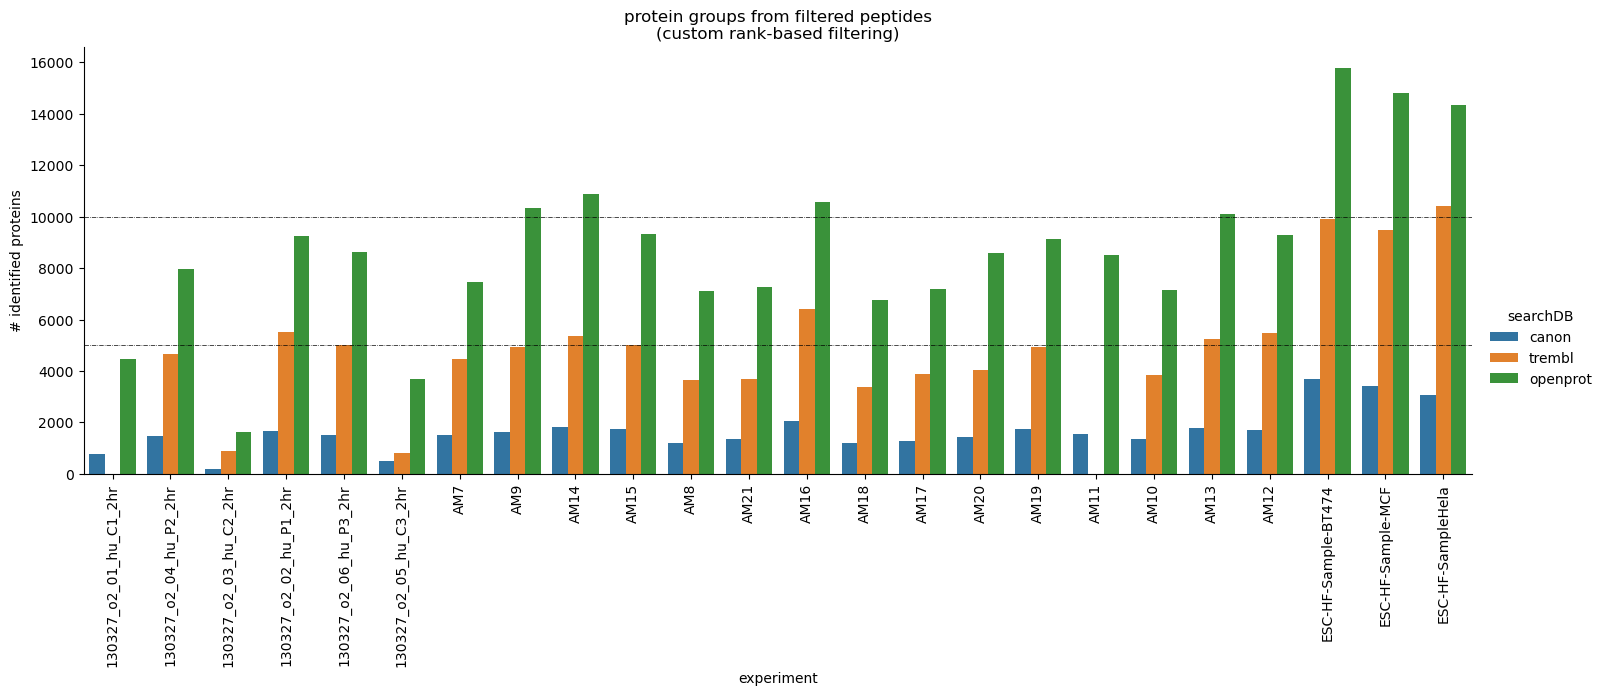

In [120]:
combo = [pd.read_csv(_) for _ in output_files]
combo = pd.concat(combo, ignore_index=True)
combo.to_csv(savefile_path, index=False, compression='gzip')

combo.proteins = combo.proteins.str.split(',')
combo = combo.explode('proteins')
combo.drop_duplicates(['proteins','experiment','searchDB'], inplace=True)

sns.catplot(data=combo, kind='count', x='experiment', hue='searchDB', aspect=3)#, palette=list(project_palette.values()))
plt.xticks(rotation=90)
plt.xlabel('experiment')
plt.ylabel('# identified proteins')
plt.axhline(10000, ls='-.', lw=.5, c='k')
plt.axhline(5000, ls='-.', lw=.5, c='k')
plt.title('protein groups from filtered peptides\n(custom rank-based filtering)')

#plt.savefig(savefig_path, dpi=300, bbox_inches='tight')